#**Milestone 5**

In [33]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv("priceoptima_processed.csv")
df.head()

,Product_ID,City,State,Country,Customer_Segment,Date,Year,Month,Time,Total_Purchases,Amount,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Ratings,products
0,8691788,Dortmund,Berlin,Germany,Regular,2023-09-18,2023,9,22:03:55,3.0,108.028757,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,5.0,Cycling shorts
1,2174773,Nottingham,England,UK,Premium,2023-12-31,2023,12,08:42:04,2.0,403.353907,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,4.0,Lenovo Tab
2,6679610,Geelong,New South Wales,Australia,Regular,2023-04-26,2023,4,04:06:29,3.0,354.477600,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,2.0,Sports equipment
3,7232460,Edmonton,Ontario,Canada,Premium,2023-08-05,2023,8,14:55:17,7.0,352.407717,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,4.0,Utility knife
4,4983775,Bristol,England,UK,Premium,2024-10-01,2024,10,16:54:07,2.0,124.276524,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,1.0,Chocolate cookies


In [35]:
df = df.rename(columns={
    "Amount": "price",
    "Total_Purchases": "quantity_sold"
})

In [38]:
# Convert time
df["hour"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.hour

# Simulate inventory
np.random.seed(42)
df["inventory"] = np.random.randint(10,150,size=len(df))

In [39]:
features = ["price", "inventory", "hour", "Month", "Ratings"]
target = "quantity_sold"

X = df[features]
y = df[target]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
# XGBoost
xgb_model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# LightGBM
lgb_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, verbose=-1)
lgb_model.fit(X_train, y_train)

LGBMRegressor(verbose=-1)

In [44]:
def evaluate(y_true, y_pred, name):
    print(f"--- {name} ---")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))
    print()

evaluate(y_test, xgb_model.predict(X_test), "XGBoost")
evaluate(y_test, lgb_model.predict(X_test), "LightGBM")

--- XGBoost ---
MAE: 2.4962693518008714
RMSE: 2.875021211393564
R2: -0.002455080031736223

--- LightGBM ---
MAE: 2.495999359317125
RMSE: 2.873334120999437
R2: -0.0012789244516819842



In [45]:
df_test = df.copy()
df_test["actual_quantity"] = df["quantity_sold"]

In [46]:
df_test["price_up"] = df_test["price"] * 1.10
df_test["price_down"] = df_test["price"] * 0.90

In [47]:
df_test["demand_up"] = xgb_model.predict(
    df_test.assign(price=df_test["price_up"])[features]
)

df_test["demand_down"] = xgb_model.predict(
    df_test.assign(price=df_test["price_down"])[features]
)

In [48]:
def best_revenue(row):
    rev_current = row["price"] * row["actual_quantity"]
    rev_up = row["price_up"] * row["demand_up"]
    rev_down = row["price_down"] * row["demand_down"]
    return max(rev_current, rev_up, rev_down)

df_test["ml_revenue"] = df_test.apply(best_revenue, axis=1)

In [49]:
def dynamic_price(row):

    price = row["price"]

    if 18 <= row["hour"] <= 22:
        price *= 1.15

    if row["hour"] >= 22 or row["hour"] <= 2:
        price *= 1.10

    if row["inventory"] < 20:
        price *= 1.25
    elif row["inventory"] < 50:
        price *= 1.12
    elif row["inventory"] > 120:
        price *= 0.85

    if row["Ratings"] >= 4.5:
        price *= 1.10

    return price

df["adjusted_price"] = df.apply(dynamic_price, axis=1)
df["rule_revenue"] = df["adjusted_price"] * df["quantity_sold"]

rule_based_revenue = df["rule_revenue"].sum()

In [50]:
# Static
static_revenue = (df["price"] * df["quantity_sold"]).sum()

# ML
ml_revenue = df_test["ml_revenue"].sum()

print("Static Revenue:", static_revenue)
print("Rule-Based Revenue:", rule_based_revenue)
print("ML Revenue:", ml_revenue)

Static Revenue: 410062551.73627484
Rule-Based Revenue: 444312371.18068576
ML Revenue: 527584474.18101305


In [51]:
ml_lift = ((ml_revenue - static_revenue) / static_revenue) * 100

print("ML Revenue Lift (%):", round(ml_lift,2))

ML Revenue Lift (%): 28.66


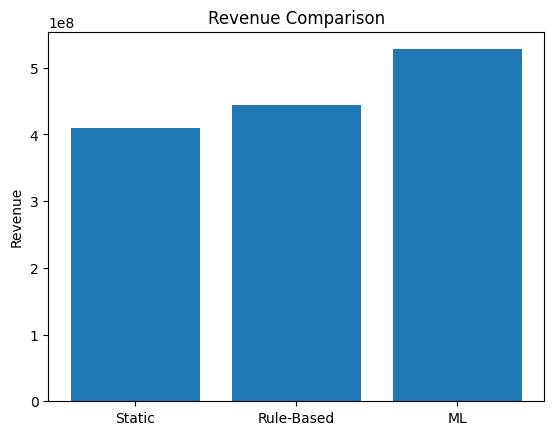

In [52]:
labels = ["Static", "Rule-Based", "ML"]
values = [static_revenue, rule_based_revenue, ml_revenue]

plt.bar(labels, values)
plt.title("Revenue Comparison")
plt.ylabel("Revenue")
plt.show()

In [53]:
print("------ Final Results ------")

print("Static Revenue:", round(static_revenue,2))
print("Rule-Based Revenue:", round(rule_based_revenue,2))
print("ML Revenue:", round(ml_revenue,2))

print("ML Revenue Lift (%):", round(ml_lift,2))

------ Final Results ------
Static Revenue: 410062551.74
Rule-Based Revenue: 444312371.18
ML Revenue: 527584474.18
ML Revenue Lift (%): 28.66
